In [1]:
import open3d as o3d
import numpy as np
import matplotlib.pyplot as plt
import rosbag
from tf.transformations import euler_from_quaternion
from tqdm import tqdm

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


INFO - 2025-09-24 20:58:10,516 - topics - topicmanager initialized


In [2]:
import open3d as o3d
import numpy as np
import matplotlib.pyplot as plt
import rosbag
from tf.transformations import euler_from_quaternion
from tqdm import tqdm


def get_grid_lineset(h_min_val, h_max_val, w_min_val, w_max_val, ignore_axis, grid_length=1, nth_line=5):
    if (h_min_val%2!=0):
        h_min_val -= 1
    if (h_max_val%2!=0):
        h_max_val += 1
    if (w_min_val%2!=0):
        w_min_val -= 1
    if (w_max_val%2!=0):
        w_max_val += 1
    
    num_h_grid = int(np.ceil((h_max_val - h_min_val) / grid_length))
    num_w_grid = int(np.ceil((w_max_val - w_min_val) / grid_length))
    
    num_h_grid_mid = num_h_grid // 2
    num_w_grid_mid = num_w_grid // 2
    
    grid_vertexes_order = np.zeros((num_h_grid, num_w_grid)).astype(np.int16)
    grid_vertexes = []
    vertex_order_index = 0
    
    for h in range(num_h_grid):
        for w in range(num_w_grid):
            grid_vertexes_order[h][w] = vertex_order_index
            if ignore_axis == 0:
                grid_vertexes.append([0, grid_length*w + w_min_val, grid_length*h + h_min_val])
            elif ignore_axis == 1:
                grid_vertexes.append([grid_length*h + h_min_val, 0, grid_length*w + w_min_val])
            elif ignore_axis == 2:
                grid_vertexes.append([grid_length*w + w_min_val, grid_length*h + h_min_val, 0])
            else:
                pass                
            vertex_order_index += 1       
            
    next_h = [0, 1]
    next_w = [1, 0]
    grid_lines = []
    grid_nth_lines = []
    for h in range(num_h_grid):
        for w in range(num_w_grid):
            here_h = h
            here_w = w
            for i in range(2):
                there_h = h + next_h[i]
                there_w = w +  next_w[i]   
                if (0 <= there_h and there_h < num_h_grid) and (0 <= there_w and there_w < num_w_grid):
                    if ((here_h % nth_line) == 0) and ((here_w % nth_line) == 0):
                        grid_nth_lines.append([grid_vertexes_order[here_h][here_w], grid_vertexes_order[there_h][there_w]])
                    elif ((here_h % nth_line) != 0) and ((here_w % nth_line) == 0) and i == 1:
                        grid_nth_lines.append([grid_vertexes_order[here_h][here_w], grid_vertexes_order[there_h][there_w]])
                    elif ((here_h % nth_line) == 0) and ((here_w % nth_line) != 0) and i == 0:
                        grid_nth_lines.append([grid_vertexes_order[here_h][here_w], grid_vertexes_order[there_h][there_w]])
                    else:
                        grid_lines.append([grid_vertexes_order[here_h][here_w], grid_vertexes_order[there_h][there_w]])

    color = (0.8, 0.8, 0.8)
    colors = [color for i in range(len(grid_lines))]
    line_set = o3d.geometry.LineSet(
        points=o3d.utility.Vector3dVector(grid_vertexes),
        lines=o3d.utility.Vector2iVector(grid_lines),
    )
    line_set.colors = o3d.utility.Vector3dVector(colors)
    
    color = (255, 0, 0)
    colors = [color for i in range(len(grid_nth_lines))]
    line_nth_set = o3d.geometry.LineSet(
        points=o3d.utility.Vector3dVector(grid_vertexes),
        lines=o3d.utility.Vector2iVector(grid_nth_lines),
    )
    line_nth_set.colors = o3d.utility.Vector3dVector(colors)
    
    return line_set, line_nth_set

def show_open3d_pcd(raw, show_origin=True, origin_size=3, 
                    show_grid=True, grid_len=1, 
                    voxel_size=0, 
                    range_min_xyz=(-80, -80, -80), range_max_xyz=(80, 80, 80)):
    '''
    - raw : numpy 2d array (size : (n, 3)) or o3d.geometry.PointCloud
    - show_origin : show origin XYZ coordinate. (X=red, Y=green, Z=Blue)
    - origin_size : size of origin coordinate.
    - show_grid : if true, show grid in xy, yz, zx plane with 'grid_len' length (default : gray line) and 5 times of 'grid_len' (default : red line)
    - voxel_size : voxel size to downsampling
    - range_min_xyz : grid min range of xyz orientation
    - range_max_xyz : grid max range of xyz orientation

    '''
    pcd = o3d.geometry.PointCloud()    
    
    if isinstance(raw, type(pcd)):
        pcd = raw
    elif isinstance(raw, np.ndarray):
        pcd.points = o3d.utility.Vector3dVector(raw)        
    if voxel_size > 0:
        pcd = pcd.voxel_down_sample(voxel_size=voxel_size)
        
    pcd_point = np.array(pcd.points)
    inrange_inds = (pcd_point[:, 0] > range_min_xyz[0]) & \
                    (pcd_point[:, 1] > range_min_xyz[1]) & \
                    (pcd_point[:, 2] > range_min_xyz[2]) & \
                    (pcd_point[:, 0] < range_max_xyz[0]) & \
                    (pcd_point[:, 1] < range_max_xyz[1]) & \
                    (pcd_point[:, 2] < range_max_xyz[2])    
    
    pcd_point = pcd_point[inrange_inds]
    filtered_raw = pcd_point
    pcd.points = o3d.utility.Vector3dVector(filtered_raw)
        
    x_min_val, y_min_val, z_min_val = range_min_xyz
    x_max_val, y_max_val, z_max_val = range_max_xyz
    
    coord = o3d.geometry.TriangleMesh().create_coordinate_frame(size=origin_size, origin=np.array([0.0, 0.0, 0.0]))
    
    ##################################### grid 생성 코드 ######################################
    lineset_yz, lineset_nth_yz = get_grid_lineset(z_min_val, z_max_val, y_min_val, y_max_val, 0, grid_len)
    lineset_zx, lineset_nth_zx = get_grid_lineset(x_min_val, x_max_val, z_min_val, z_max_val, 1, grid_len)
    lineset_xy, lineset_nth_xy = get_grid_lineset(y_min_val, y_max_val, x_min_val, x_max_val, 2, grid_len) 
    ###########################################################################################
    
    # set front, lookat, up, zoom to change initial view
    if show_origin and show_grid:
        o3d.visualization.draw_geometries([pcd, coord,
                                           lineset_nth_yz, lineset_nth_zx, lineset_nth_xy,
                                           lineset_xy, lineset_yz, lineset_zx
                                          ])  
    elif show_origin and not show_grid:
        o3d.visualization.draw_geometries([pcd, coord])
    elif not show_origin and show_grid:
        o3d.visualization.draw_geometries([pcd,
                                           lineset_nth_yz, lineset_nth_zx, lineset_nth_xy,
                                           lineset_xy, lineset_yz, lineset_zx
                                          ])  
    else:
        o3d.visualization.draw_geometries([pcd])  

def pose2d_to_mat4(x, y, yaw):
    """
    2D pose (x, y, yaw) → 4x4 homogeneous transform (SE3)
    yaw 단위: rad
    """
    c, s = np.cos(yaw), np.sin(yaw)
    T = np.eye(4)
    T[0,0], T[0,1] = c, -s
    T[1,0], T[1,1] = s,  c
    T[0,3], T[1,3] = x, y
    return T


def T_w_c_to_T_w_o(T_w_c):
    """
    카메라 좌표계에서 오브젝트 좌표계로 변환
    T_w_c: 월드 좌표계에서 카메라 좌표계로의 변환 행렬 (4x4)
    T_w_o: 월드 좌표계에서 오브젝트 좌표계로의 변환 행렬 (4x4)
    """
    # 카메라 좌표계에서 오브젝트 좌표계로의 변환 행렬 (예: 90도 회전)
    T_c_o = np.array([[0, -1, 0, 0],
                      [0, 0, -1, 0],
                      [1, 0, 0, 0],
                      [0, 0, 0, 1]])
    
    # 월드 좌표계에서 오브젝트 좌표계로의 변환 행렬 계산
    T_w_o = np.dot(T_w_c, T_c_o)
    
    return T_w_o

def T_w_o_to_T_w_c(T_w_o):
    """
    오브젝트 좌표계에서 카메라 좌표계로 변환
    T_w_o: 월드 좌표계에서 오브젝트 좌표계로의 변환 행렬 (4x4)
    T_w_c: 월드 좌표계에서 카메라 좌표계로의 변환 행렬 (4x4)
    """
    # 오브젝트 좌표계에서 카메라 좌표계로의 변환 행렬 (예: -90도 회전)
    T_o_c = np.array([[0, 0, 1, 0],
                      [-1, 0, 0, 0],
                      [0, -1, 0, 0],
                      [0, 0, 0, 1]])
    
    # 월드 좌표계에서 카메라 좌표계로의 변환 행렬 계산
    T_w_c = np.dot(T_w_o, T_o_c)
    
    return T_w_c


In [20]:

# ===============================
# 1. 데이터 로드 (사용자 준비)
# ===============================
# 예시: rgb_list, depth_list, vo_poses는 미리 준비된 리스트
#  - rgb_list: (H, W, 3) numpy array
#  - depth_list: (H, W) numpy array, 사람 영역은 mask된 depth
#  - vo_poses: 각 프레임의 VO pose (4x4 numpy array)

rgb_list = []      # 사용자 데이터
rgb_time = []  # 사용자 데이터
depth_list = []    # 사용자 데이터
depth_time = []  # 사용자 데이터
vo_poses = []      # VO trajectory (각각 4x4 pose)
vo_time = []  # 사용자 데이터
object_detections = []  # 사용자 데이터
object_det_time = []  # 사용자 데이터

bagfile = "/media/seungwoo/T5_JSW/rosbag_alchemist_2025_08_01/2F/3_comp/9,10,11,12/2025-08-01-16-45-07.bag"
odom_topic = "/zed2/zed_node/odom"
depth_topic = "/zed_client/image_depth_masked"
rgb_topic = "/zed2/zed_node/rgb/image_rect_color"
obj_det_topic = "/zed2/zed_node/obj_det/objects"

# fig, ax = plt.subplots(1, 1)
# plt.ion()
# ax.set_title("Depth Image")
# ax.set_xlabel("X")
# ax.set_ylabel("Y")
# img_plot = ax.imshow(np.zeros((480, 640)), cmap='gray')
# colorbar = plt.colorbar(img_plot, ax=ax)
# plt.pause(0.1)  # 잠시 표시

example_rgb_msg = None


with rosbag.Bag(bagfile) as bag:
    for topic, msg, t in tqdm(bag.read_messages(topics=[rgb_topic, depth_topic, odom_topic, obj_det_topic]), desc="Loading data from bag",):
        if topic == rgb_topic:
            if example_rgb_msg is None:
                example_rgb_msg = msg
            rgb = np.frombuffer(msg.data, dtype=np.uint8).reshape(msg.height, msg.width, -1)
            rgb_list.append(rgb.copy())
            rgb_time.append(t)
        elif topic == depth_topic:
            depth = np.frombuffer(msg.data, dtype=np.float32).reshape(msg.height, msg.width)
            # img_plot.set_data(depth)
            # img_plot.set_clim(vmin=np.nanmin(depth), vmax=np.nanmax(depth))
            # plt.pause(0.001)
            depth_list.append(depth.copy())
            depth_time.append(t)
        elif topic == odom_topic:
            x = msg.pose.pose.position.x
            y = msg.pose.pose.position.y
            z = 0  # 2D이므로 z=0 고정

            # orientation quaternion -> yaw
            q = msg.pose.pose.orientation
            quat = [q.x, q.y, q.z, q.w]
            roll, pitch, yaw = euler_from_quaternion(quat)
            T = pose2d_to_mat4(x, y, yaw)
            vo_poses.append(T)
            vo_time.append(t)
        elif topic == obj_det_topic:
            object_detections.append(msg)
            object_det_time.append(t)

# 시간 동기화 (가장 가까운 시간의 depth/rgb/vo 매칭)
synced_rgb = []
synced_depth = []
synced_vo_poses = []
synced_object_detections = []
for i in range(len(depth_time)):
    depth_t = depth_time[i]
    # 가장 가까운 rgb 찾기
    rgb_diffs = [abs((depth_t - rt).to_sec()) for rt in rgb_time]
    rgb_idx = np.argmin(rgb_diffs)
    # 가장 가까운 vo 찾기
    vo_diffs = [abs((depth_t - vt).to_sec()) for vt in vo_time]
    vo_idx = np.argmin(vo_diffs)

    # 가장 가까운 object detection 찾기

    obj_diffs = []
    for ot in object_det_time:
        if (depth_t - ot).to_sec() > 0:
            obj_diffs.append(abs((depth_t - ot).to_sec()))
        else:
            obj_diffs.append(float('inf'))
    obj_idx = np.argmin(obj_diffs)


    synced_rgb.append(rgb_list[rgb_idx])
    synced_depth.append(depth_list[i])  # depth는 현재 인덱스 사용
    synced_vo_poses.append(vo_poses[vo_idx])
    synced_object_detections.append(object_detections[obj_idx] if obj_diffs[obj_idx] < 0.1 else None)
    if obj_diffs[obj_idx] >= 0.1:
        print(f"No object detection within 0.1s for depth frame at time {depth_t.to_sec()}s")


rgb_list = synced_rgb
depth_list = synced_depth
vo_poses = synced_vo_poses
object_detections = synced_object_detections
vo_cam_pose = T_w_o_to_T_w_c(synced_vo_poses)  # 카메라 좌표계에서의 VO pose (4x4 numpy array)


Loading data from bag: 7706it [00:01, 5515.98it/s]


[(387, 2), (612, 2), (612, 601), (387, 601)]


float

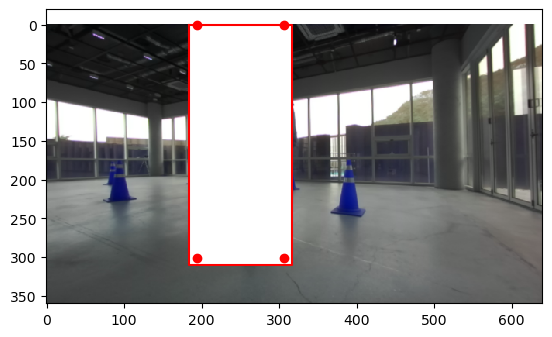

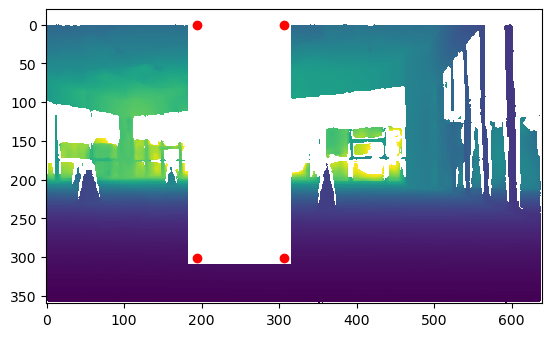

In [22]:
i = 300


# print(rgb_list[i].shape)

rGlobalMin = 0
cGlobalMin = 0
rGlobalMax = 320-1
cGlobalMax = 640-1
x_padding = 10
y_padding = 10

bound = [object_detections[i].objects[0].bounding_box_2d.corners[j].kp for j in range(4)]
print(bound)
bound = np.array(bound, dtype=int) /2

rMin = max(int(np.min(bound[:,1])) - y_padding, rGlobalMin)
rMax = min(int(np.max(bound[:,1])) + y_padding, rGlobalMax)
cMin = max(int(np.min(bound[:,0])) - x_padding, cGlobalMin)
cMax = min(int(np.max(bound[:,0])) + x_padding, cGlobalMax)

rgb_test = rgb_list[i].copy()
depth_test = depth_list[i].copy()
rgb_test[rMin:rMax, cMin:cMax] = 0
depth_test[rMin:rMax, cMin:cMax] = np.NaN

plt.imshow(rgb_test)
plt.plot([cMin, cMax, cMax, cMin, cMin], [rMin, rMin, rMax, rMax, rMin], 'r-')

plt.scatter(bound[:,0], bound[:,1], c='r')

plt.figure()
plt.imshow(depth_test)
plt.scatter(bound[:,0], bound[:,1], c='r')
type(np.NaN)



In [24]:
rGlobalMin = 0
cGlobalMin = 0
rGlobalMax = 320-1
cGlobalMax = 640-1
x_padding = 10
y_padding = 10


for i in range(len(rgb_list)):
    if object_detections[i].objects == []:
        continue
    bound = [object_detections[i].objects[0].bounding_box_2d.corners[j].kp for j in range(4)]
    bound = np.array(bound, dtype=int) /2

    rMin = max(int(np.min(bound[:,1])) - y_padding, rGlobalMin)
    rMax = min(int(np.max(bound[:,1])) + y_padding, rGlobalMax)
    cMin = max(int(np.min(bound[:,0])) - x_padding, cGlobalMin)
    cMax = min(int(np.max(bound[:,0])) + x_padding, cGlobalMax)

    rgb_list[i][rMin:rMax, cMin:cMax] = 0
    depth_list[i][rMin:rMax, cMin:cMax] = np.NaN
    if i % 100 == 0:
        print(f"Processed {i}/{len(rgb_list)} frames")

Processed 0/1920 frames
Processed 100/1920 frames
Processed 200/1920 frames
Processed 300/1920 frames
Processed 400/1920 frames
Processed 500/1920 frames
Processed 600/1920 frames
Processed 700/1920 frames
Processed 800/1920 frames
Processed 900/1920 frames
Processed 1000/1920 frames
Processed 1100/1920 frames
Processed 1200/1920 frames
Processed 1300/1920 frames
Processed 1400/1920 frames
Processed 1500/1920 frames
Processed 1600/1920 frames
Processed 1700/1920 frames
Processed 1800/1920 frames


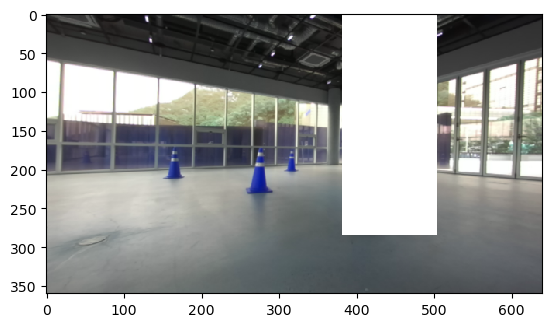

In [28]:
plt.imshow(rgb_list[200])

In [29]:
# save new bag file with trimmed data
#  - rgb_list, depth_list, vo_poses, object_detections
# ------------------------------
# 시간 동기화 (가장 가까운 시간의 depth/rgb/vo 매칭)

from sensor_msgs.msg import Image, CameraInfo, PointCloud2
from nav_msgs.msg import Odometry
from std_msgs.msg import Header



bagfile_trim = bagfile.replace(".bag", "_trimmed.bag")

with rosbag.Bag(bagfile_trim, 'w') as out_bag:
    for i in range(len(depth_list)):
        # RGB 이미지 저장
        rgb_msg = Image()
        rgb_msg.header.stamp = depth_time[i]
        rgb_msg.height = rgb_list[i].shape[0]
        rgb_msg.width = rgb_list[i].shape[1]
        rgb_msg.encoding = example_rgb_msg.encoding  # "rgba8"
        rgb_msg.is_bigendian = example_rgb_msg.is_bigendian
        rgb_msg.step = example_rgb_msg.step
        rgb_msg.data = rgb_list[i].tobytes()
        out_bag.write(rgb_topic, rgb_msg, depth_time[i])

        # Depth 이미지 저장
        depth_msg = Image()
        depth_msg.header.stamp = depth_time[i]
        depth_msg.height = depth_list[i].shape[0]
        depth_msg.width = depth_list[i].shape[1]
        depth_msg.encoding = "32FC1"
        depth_msg.is_bigendian = 0
        depth_msg.step = depth_list[i].shape[1] * 4
        depth_msg.data = depth_list[i].astype(np.float32).tobytes()
        out_bag.write(depth_topic, depth_msg, depth_time[i])

        # VO 포즈 저장
        vo_msg = Odometry()
        vo_msg.header.stamp = depth_time[i]
        vo_msg.header.frame_id = "odom"
        vo_msg.pose.pose.position.x = vo_poses[i][0, 3]
        vo_msg.pose.pose.position.y = vo_poses[i][1, 3]
        vo_msg.pose.pose.position.z = 0.0  # 2D이므로 z=0 고정

        # VO 포즈의 orientation quaternion 계산
        yaw = np.arctan2(vo_poses[i][1, 0], vo_poses[i][0, 0])
        quat = [0, 0, np.sin(yaw / 2), np.cos(yaw / 2)]
        vo_msg.pose.pose.orientation.x = quat[0]
        vo_msg.pose.pose.orientation.y = quat[1]
        vo_msg.pose.pose.orientation.z = quat[2]
        vo_msg.pose.pose.orientation.w = quat[3]

        out_bag.write(odom_topic, vo_msg, depth_time[i])

        